In [1]:
import polars as pl
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from modules.design import bc_palette, b_order, b_cat, set_yticks, set_frame, set_hatch

mpl.rcParams['font.family'] = 'Liberation Serif'


# Helper functions

In [2]:
bc_translation = {
    "jerryscript": "JerryScript",
    "micropython": "MicroPython",
    "lua": "Lua",
    "wamr": "WAMR",
    "wamr-fast": "WAMR (fast)",
    "micro-bpf": "µBPF",
    "native": "Native"
}

def update_env(df: pl.DataFrame):
    return df.with_columns(
        environment=pl.col("environment").map_elements(lambda e: bc_translation.get(e, e)),
    )

def check_completeness(df: pl.DataFrame):
    difference = set(df["environment"].unique().to_list()).symmetric_difference(bc_palette.keys())
    if difference:
        raise ValueError(f"Difference: {difference}")


## Data Import

In [3]:
mem_file = "../data/memory/section_sizes.csv"
mem_df = update_env(pl.read_csv(mem_file))
mem_df = mem_df.with_columns(pl.col("benchmark").str.replace("nettle-sha256", "sha256"))
check_completeness(mem_df)

dyn_mem_file = "../data/memory/dynamic_memory.csv"
dyn_mem_df = update_env(pl.read_csv(dyn_mem_file))
dyn_mem_df = dyn_mem_df.with_columns(pl.col("benchmark").str.replace("nettle-sha256", "sha256"))

sh_file = "../configs/memory_requirements.csv"
sh_df = update_env(pl.read_csv(sh_file))
sh_df = sh_df.with_columns(pl.col("benchmark").str.replace("nettle-sha256", "sha256"))
sh_df = sh_df.rename({"HEAP": "heap"})
check_completeness(sh_df)


ram_segments = [".bss", ".data"]
rom_segments = [".text"]

dyn_mem_df = dyn_mem_df.with_columns(category=pl.lit("Runtime"), type=pl.lit("dynamic"), size=pl.col("allocated_memory")).drop("allocated_memory").select(["benchmark", "board", "environment", "category", "type", "size"])

rom_df = mem_df.filter(pl.col("type").is_in(rom_segments))

ram_df = mem_df.filter(pl.col("type").is_in(ram_segments))
ram_df = ram_df.select(["benchmark", "board", "environment", "category", "type", "size"]).extend(other=dyn_mem_df).sort(pl.col("benchmark").cast(pl.Enum(b_order)))


stack_df = (
    sh_df.select(["benchmark", "board", "environment", "RIOT_STACK"])
    .with_columns(category=pl.lit("Stack"), type=pl.lit("os"), riot_stack=pl.col("RIOT_STACK")).drop("RIOT_STACK")
)

heap_df = (
    sh_df.select(["benchmark", "board", "environment", "heap"])
    .filter(pl.col("heap") != 0).with_columns(pl.when(pl.col("environment")=="JerryScript").then(pl.col("heap") * 1000).otherwise(pl.col("heap")))
)

# Memory Stats

In [4]:

stats_ram_df = ram_df.group_by(["benchmark", "board", "environment"]).agg(size=pl.col("size").sum())
least_ram_env = (
    stats_ram_df.filter(pl.col("environment") != "Native")
    .group_by("benchmark", maintain_order=True)
    .agg(pl.all().sort_by("size").first())
    .rename({"environment": "environment_least_rom", "size": "size_rom"})
)
stats_ram_df = stats_ram_df.group_by(["board", "environment"]).agg(ram_mean=pl.col("size").mean(), ram_max=pl.col("size").max(), ram_min=pl.col("size").min())

stats_rom_df = rom_df.group_by(["benchmark", "board", "environment"]).agg(size=pl.col("size").sum())
least_rom_env = (
    stats_rom_df.filter(pl.col("environment") != "Native")
    .group_by("benchmark", maintain_order=True)
    .agg(pl.all().sort_by("size").first())
    .rename({"environment": "environment_least_ram", "size": "size_ram"})
)
stats_rom_df = stats_rom_df.group_by(["board", "environment"]).agg(rom_mean=pl.col("size").mean(), rom_max=pl.col("size").max(), rom_min=pl.col("size").min())

stats_mem_df = stats_ram_df.join(stats_rom_df, on=["board", "environment"], how="inner")
stats_mem_df = stats_mem_df.sort(pl.col("environment").cast(pl.Enum(bc_palette.keys())))

best_env_df = least_rom_env.join(least_ram_env, on=["benchmark", "board"], how="inner")

stats_mem_df.show(limit=None)
least_ram_env.show(limit=None)


board,environment,ram_mean,ram_max,ram_min,rom_mean,rom_max,rom_min
str,str,f64,i64,i64,f64,i64,i64
"""nrf52840dk""","""JerryScript""",26054.666667,59648,10652,217732.666667,322010,117579
"""nrf52840dk""","""MicroPython""",39569.0,140308,10560,151537.666667,213418,135754
"""nrf52840dk""","""Lua""",64917.333333,164316,28532,182325.0,237568,166936
"""nrf52840dk""","""WAMR""",29436.25,82060,17823,100953.666667,125279,96727
"""nrf52840dk""","""WAMR (fast)""",36690.25,102827,18841,103648.666667,127974,99422
"""nrf52840dk""","""µBPF""",14558.0,23632,11700,105380.0,180386,91614
"""nrf52840dk""","""Native""",4396.666667,10860,1860,15821.666667,23697,13185


benchmark,board,environment_least_rom,size_rom
str,str,str,i64
"""statemate""","""nrf52840dk""","""µBPF""",11932
"""nsichneu""","""nrf52840dk""","""µBPF""",11912
"""huffbench""","""nrf52840dk""","""MicroPython""",21964
"""tarfind""","""nrf52840dk""","""MicroPython""",14556
"""xgboost""","""nrf52840dk""","""µBPF""",11700
"""sha256""","""nrf52840dk""","""µBPF""",11992
"""ud""","""nrf52840dk""","""MicroPython""",10560
"""mont64""","""nrf52840dk""","""JerryScript""",10652
"""crc_32""","""nrf52840dk""","""µBPF""",11700


# Limits RAM and ROM

Text(0.5, 0.98, 'RAM (right) and ROM (left) with the c1 and c2 limits')

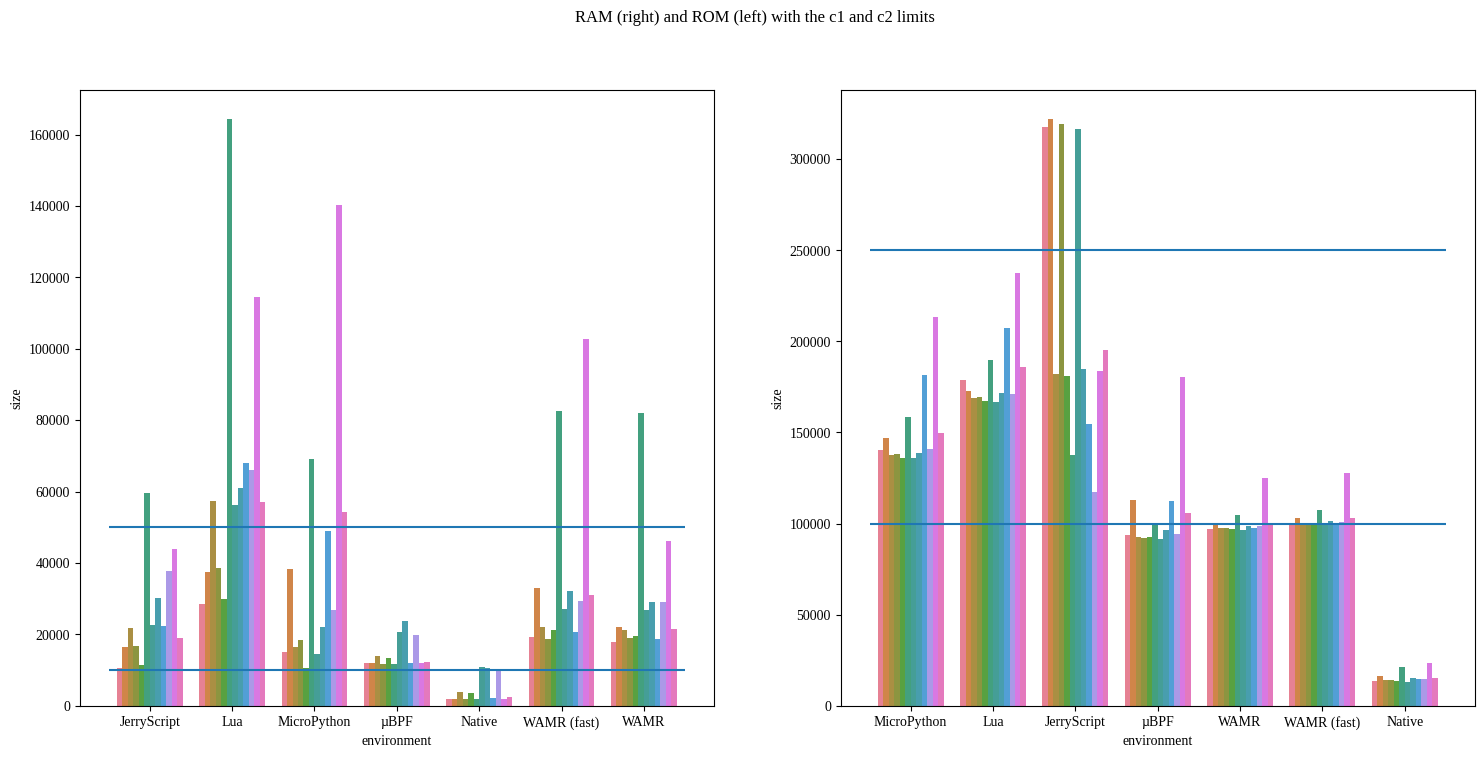

In [5]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(ax=axl, data=ram_df.group_by(["benchmark", "board", "environment"]).agg(size=pl.col("size").sum()), x="environment", y="size", hue="benchmark", hue_order=b_order)
sns.barplot(ax=axr, data=rom_df.group_by(["benchmark", "board", "environment"]).agg(size=pl.col("size").sum()), x="environment", y="size", hue="benchmark", hue_order=b_order)

axl.legend().remove()
axr.legend().remove()

axl.hlines([10000, 50000], -0.5, 6.5)
axr.hlines([100000, 250000], -0.5, 6.5)
fig.suptitle("RAM (right) and ROM (left) with the c1 and c2 limits")


# Binary Size

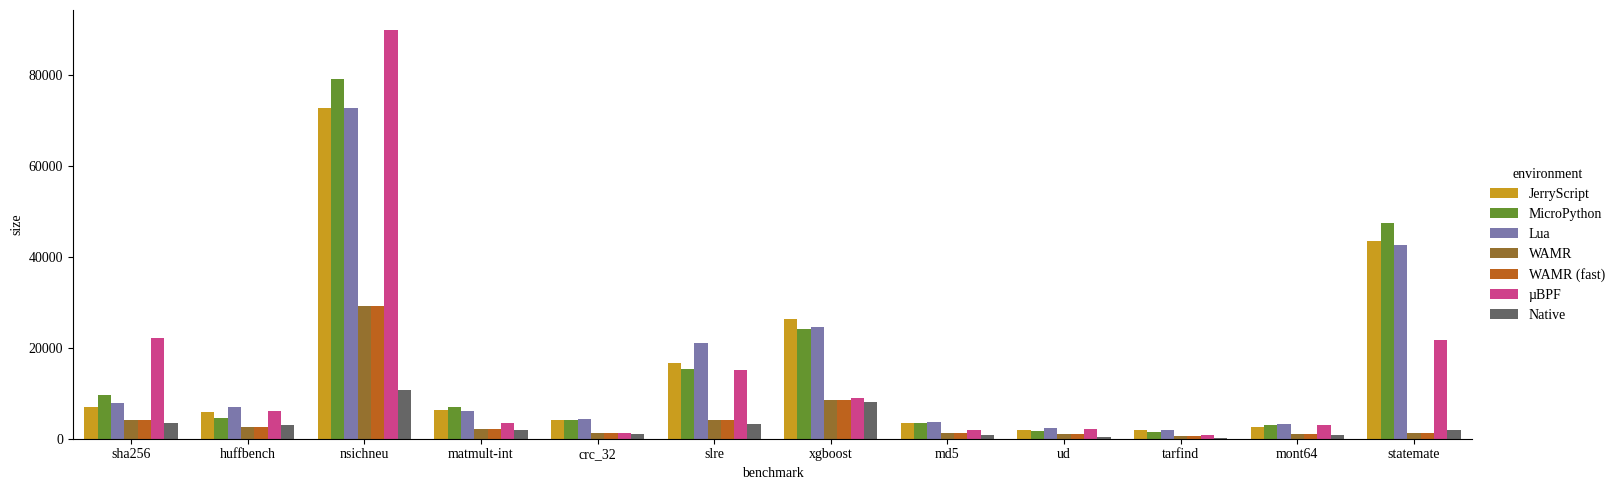

In [6]:
bb_df = rom_df.filter(pl.col("category") == "Application").group_by(["benchmark", "board", "environment"]).agg(pl.col("size").sum())
sns.catplot(data=bb_df, x="benchmark", y="size", hue="environment", hue_order=bc_palette.keys(), palette=bc_palette, kind="bar", aspect=3.0)


# Theoretical Heap vs Measured Heap
It should be 10% (thats our margin) but fo JerryScript it varies since we can only specify the HEAP in a KiB granularity

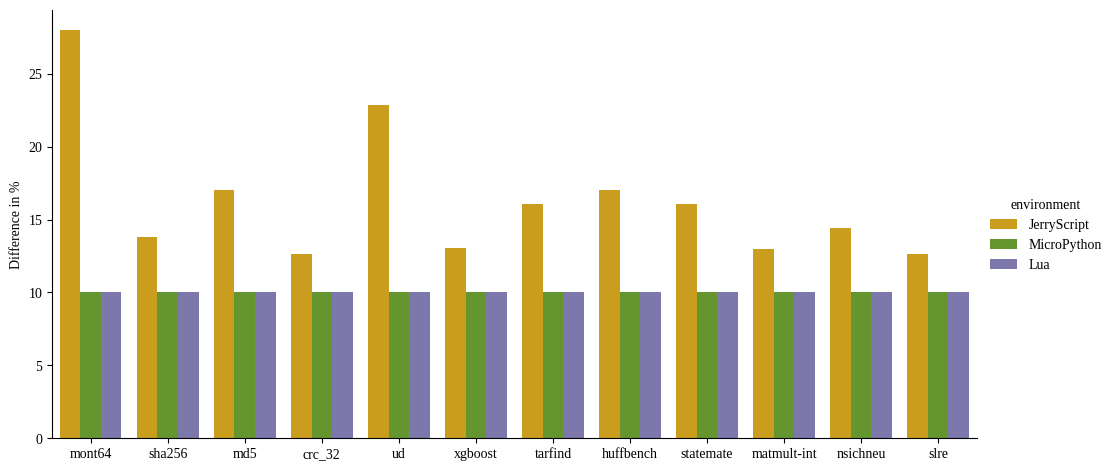

In [7]:

heap_diff_df = ram_df.filter(pl.col("category") == "Heap").select(["benchmark", "board", "environment", "size"])
heap_diff_df = heap_df.filter(pl.col("heap") != 0).join(heap_diff_df, on=["benchmark", "board", "environment"]).with_columns(diff=(pl.col("size") / pl.col("heap") - 1.0) * 100)

p = sns.catplot(heap_diff_df, x="benchmark", y="diff", hue="environment", aspect=2.0, kind="bar", hue_order=list(bc_palette.keys())[:3], palette=dict(list(bc_palette.items())[:3]))
p.set_axis_labels("", "Difference in %")
p.set_titles("Size Difference Measured vs Theoretical")

## ROM
   - ROM is the .text section (our build system does not produce a .rodata)

In [8]:
CATEGORY_TO_CATEGORY = {
    "Kernel": "Multi-Purpose OS",
    "Runtime": "Runtime",
    "Application": "Application"
}

def classify_category(cat: str) -> str:
    return CATEGORY_TO_CATEGORY.get(cat, "Other")

rom_categorized_df = rom_df.select(["benchmark", "board", "environment", "category", "size"]).with_columns(pl.col("category").map_elements(classify_category))
rom_categorized_df = rom_categorized_df.group_by(["benchmark", "board", "environment", "category"]).agg(pl.col("size").sum()).sort(pl.col("benchmark").cast(pl.Enum(b_order)))

rom_categorized_df = rom_categorized_df.pivot(on="category", values="size").fill_null(0)

## JerryScript stats

In [9]:
esnext_benchmarks = ["mont64", "sha256", "crc_32", "tarfind"]
es51_benchmarks = ["md5", "ud", "huffbench", "slre"]
min_benchmarks = ["xgboost", "statemate", "matmult-int", "nsichneu"]

js_rom_df = rom_categorized_df.filter(pl.col("environment") == "JerryScript")

js_rom_df = js_rom_df.with_columns(
    pl.when(pl.col("benchmark").is_in(min_benchmarks)).then(pl.lit("min"))
      .when(pl.col("benchmark").is_in(es51_benchmarks)).then(pl.lit("es51"))
      .when(pl.col("benchmark").is_in(esnext_benchmarks)).then(pl.lit("esnext"))
      .alias("profile")
).filter(pl.col("profile").is_not_null())

js_rom_df = js_rom_df.group_by(["board", "environment", "profile"]).agg(
    os=pl.col("Multi-Purpose OS").mean(),
    os_std=pl.col("Multi-Purpose OS").std(),
    runtime=pl.col("Runtime").mean(),
    runtime_std=pl.col("Runtime").std(),
    app=pl.col("Application").mean(),
    app_std=pl.col("Application").std(),
)

min_values = js_rom_df.filter(pl.col("profile") == "min").select("os", "runtime").row(0)
es51_values = js_rom_df.filter(pl.col("profile") == "es51").select("os", "runtime").row(0)
esnext_values = js_rom_df.filter(pl.col("profile") == "esnext").select("os", "runtime").row(0)

print(f"Profile minimal (OS/runtime): {min_values}")
print(f"Profile es5.1 (OS/runtime/total)  : {es51_values} -> ({es51_values[0] / min_values[0]:.0%}, {es51_values[1] / min_values[1]:.0%}, {(es51_values[0] + es51_values[1]) / (min_values[0] + min_values[1]):.0%}) (relative to minimal)")
print(f"Profile esnext.1 (OS/runtime/total)  : {esnext_values} -> ({esnext_values[0] / min_values[0]:.0%}, {esnext_values[1] / min_values[1]:.0%}, {(esnext_values[0] + esnext_values[1]) / (min_values[0] + min_values[1]):.0%}) (relative to minimal)")


Profile minimal (OS/runtime): (20558.0, 90675.0)
Profile es5.1 (OS/runtime/total)  : (43336.0, 135279.0) -> (211%, 149%, 161%) (relative to minimal)
Profile esnext.1 (OS/runtime/total)  : (50953.0, 263480.0) -> (248%, 291%, 283%) (relative to minimal)


## ROM Plot

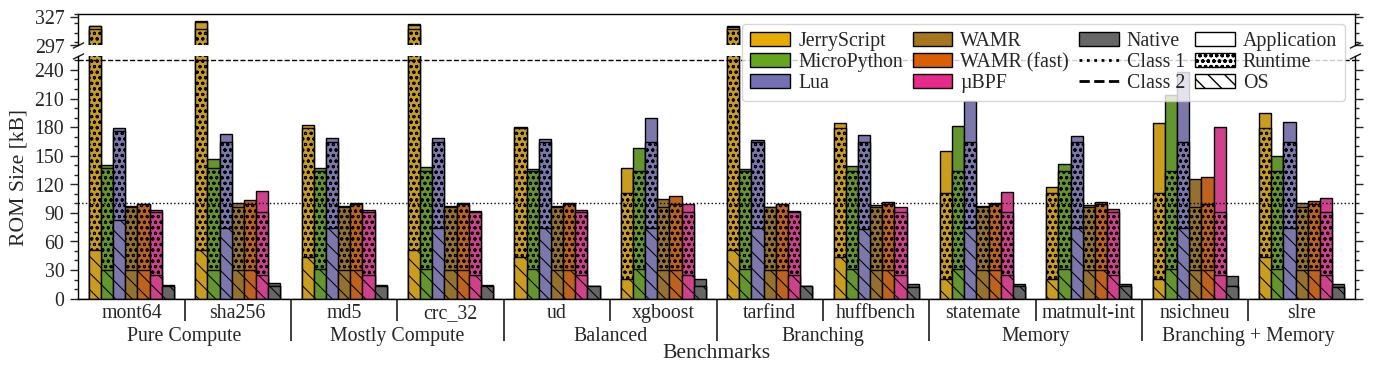

In [10]:
### CONSTANTS ###
break_point = 255_000
break_cont = 297_000
step_size = 30_000

upper_n_steps = (330_000 - break_cont) / step_size
lower_n_steps = break_point / step_size

### FIGURE SETUP ###
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig, (ax_upper, ax) = plt.subplots(2, 1, sharex=True, figsize=(14, 4), gridspec_kw={'height_ratios': [upper_n_steps, lower_n_steps]})

### DATA PREPARATION ###
rom_cumulative_df = rom_categorized_df.with_columns(
    runtime_os = pl.col("Runtime") + pl.col("Multi-Purpose OS"),
    app_runtime_os = pl.col("Runtime") + pl.col("Multi-Purpose OS") + pl.col("Application"),
    total = pl.col("Runtime") + pl.col("Multi-Purpose OS") + pl.col("Application") + pl.col("Other")
)

### PLOTTING BARS ###
for a in [ax, ax_upper]:
    sns.barplot(ax=a, x="benchmark", y="total", data=rom_cumulative_df, hue="environment", hue_order=bc_palette.keys(), palette={k: "#808080" for k, c in bc_palette.items()})
    known_patches = set(ax.patches)
    upper_bar = sns.barplot(ax=a, x="benchmark", y="app_runtime_os", data=rom_cumulative_df, hue="environment", hue_order=bc_palette.keys(), palette=bc_palette)
    set_hatch(upper_bar, known_patches, "")
    middle_bar = sns.barplot(ax=a, x="benchmark", y="runtime_os", data=rom_cumulative_df, hue="environment", hue_order=bc_palette.keys(), palette=bc_palette)
    set_hatch(middle_bar, known_patches, "ooo")
    lower_bar =sns.barplot(ax=a, x="benchmark", y="Multi-Purpose OS", data=rom_cumulative_df, hue="environment", hue_order=bc_palette.keys(), palette=bc_palette)
    set_hatch(lower_bar, known_patches, "\\\\")

### REFERENCE LINES (C1 an C2) ###
ax.hlines([250_000], -0.5, 11.5, color="black", linestyle="--", linewidth=1.0)
ax.hlines([100_000], -0.5, 11.5, color="black", linestyle=":", linewidth=1.0)

### LEGEND ###
handles = []

# Environments
for language, c in bc_palette.items():
    handles.append(Patch(facecolor=c, edgecolor="black", label=language))
# The C1 and C2 lines
handles.extend(
    [
        Line2D([0], [0], color="black", linestyle=":", linewidth=2, label="Class 1"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Class 2")
    ]
)
# Hatch
handles.append(Patch(edgecolor="black", facecolor="none", hatch="", label="Application"))
handles.append(Patch(edgecolor="black", facecolor="none", hatch="ooo", label="Runtime"))
handles.append(Patch(edgecolor="black", facecolor="none", hatch="\\\\", label="OS"))

ax_upper.legend(handles=handles, loc="upper right", ncol=4, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5)
ax.legend().remove()

### TEXT / LABELS ###
ax_upper.set_ylabel("")
ax_upper.set_xlabel("")
ax.set_xlabel("Benchmarks")
ax.set_ylabel("ROM Size [kB]")
ax.set_title("")

### SECONDARY X-AXES (CATEGORY LABELS & DIVIDERS) ###
ax.set_xlim(-0.5, 11.5)
minx, maxx = ax.get_xlim()
sec = ax.secondary_xaxis(location=0)
sec.set_xticks(np.arange(minx + 1, maxx, 2), labels=b_cat)

divider_axis = ax.secondary_xaxis(location=0)
divider_axis.set_xticks(np.arange(minx + 2, maxx, 2), labels=[""] * 5)

### AXIS LIMITS ###
ax.set_ylim(0, 330_000)
miny, maxy = ax.get_ylim()
ax.set_ylim(0, break_point)
ax_upper.set_ylim(break_cont, maxy)

### Y-AXIS FORMATTING ###
set_yticks(ax_upper, step_size, 10000, both_sides=True, start_offset=break_cont)
ax_upper.ticklabel_format(axis='y', style='sci', scilimits=(3,3))
ax_upper.yaxis.get_offset_text().set_visible(False)

ax.ticklabel_format(axis='y', style='sci', scilimits=(3,3))
ax.yaxis.get_offset_text().set_visible(False)
set_yticks(ax, step_size, 10000, both_sides=True)

### PADDING ###
ax.xaxis.labelpad = 15
ax.tick_params(axis='x', pad=-2)
ax.tick_params(axis='y', pad=4)
sec.tick_params(axis='x', pad=4)
sec.tick_params(axis='x', length=16)
divider_axis.tick_params(axis='x', length=30)

### GRID & FRAME ###
ax_upper.grid(False)
ax.grid(False)
set_frame(ax_upper, "black", 1)
set_frame(ax, "black", 1)

### BROKEN-AXIS VISUALS ###
ax.spines.top.set_visible(False)
ax_upper.spines.bottom.set_visible(False)
ax_upper.set_zorder(1)

slope = .5

kwargs = dict(marker=[(-1, -slope), (1, slope)], markersize=8,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)

ax_upper.plot([0, 1], [0, 0], transform=ax_upper.transAxes, **kwargs)
ax.plot([0, 1], [1, 1], transform=ax.transAxes, **kwargs)

### LAYOUT & EXPORT ###
plt.tight_layout()
fig.subplots_adjust(hspace=0.075)
plt.savefig("figures/rom.pdf", bbox_inches="tight", format="pdf")

# RAM
The ram is the .bss and .data segment plus the memory allocated by the HLL-VM at runtime (on the RIOT heap which is different from the HLL-VM heap.
The HLL-VM heap is always placed in the .data section.
The stack is either:
   - shared: micropython
   - allocated on its own internal heap: lua
   - part of the .data segment: jerryscript, wamr
   - fixed sized and dynamically allocated: micro-bpf


In [11]:
CATEGORY_TO_CATEGORY = {
    "Kernel": "Multi-Purpose OS",
    "Runtime": "Runtime",
    "Application": "Runtime",
    "Heap": "Heap",
    "Stack": "Stack"
}

def classify_category(cat: str) -> str:
    return CATEGORY_TO_CATEGORY.get(cat, "Other")

ram_categorized_df = ram_df.select(["benchmark", "board", "environment", "category", "size"]).with_columns(pl.col("category").map_elements(classify_category))
ram_categorized_df = ram_categorized_df.group_by(["benchmark", "board", "environment", "category"]).agg(pl.col("size").sum()).sort(pl.col("benchmark").cast(pl.Enum(b_order)))

ram_categorized_df = ram_categorized_df.pivot(on="category", values="size").fill_null(0)


## OS ROM

In [12]:

stackfree_df = ram_categorized_df.join(stack_df.select(["benchmark", "board", "environment", "riot_stack"]), on=["benchmark", "board", "environment"], how="full", coalesce=True).with_columns(stack_free_os=pl.col("Multi-Purpose OS") - pl.col("riot_stack"))


### OS without Stack for each benchmark

Text(0.5, 0.98, 'Os without Stack')

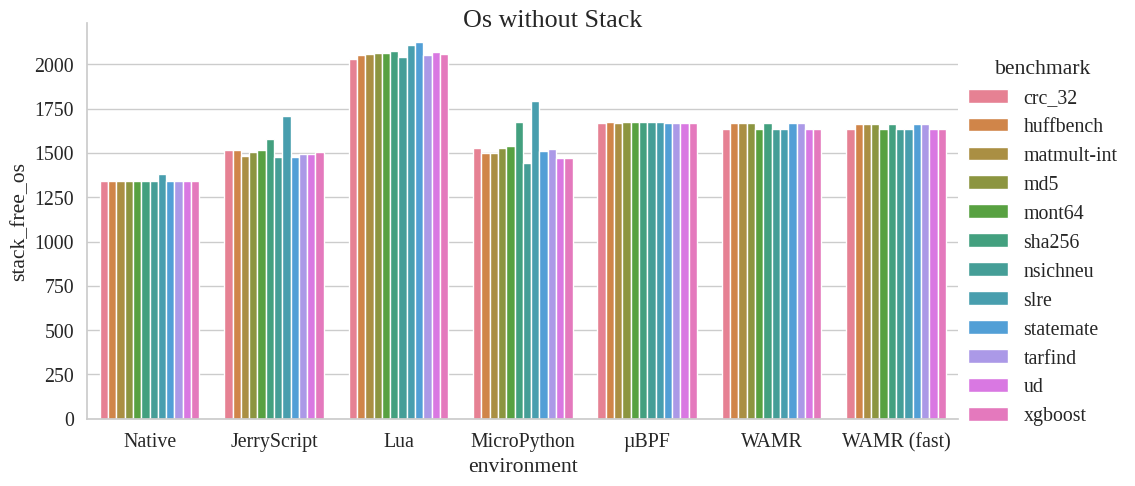

In [13]:
g = sns.catplot(stackfree_df, x="environment", y="stack_free_os", hue="benchmark", aspect=2.0, kind="bar")
g.figure.suptitle("Os without Stack")


Text(0.5, 0.98, 'RIOS stack')

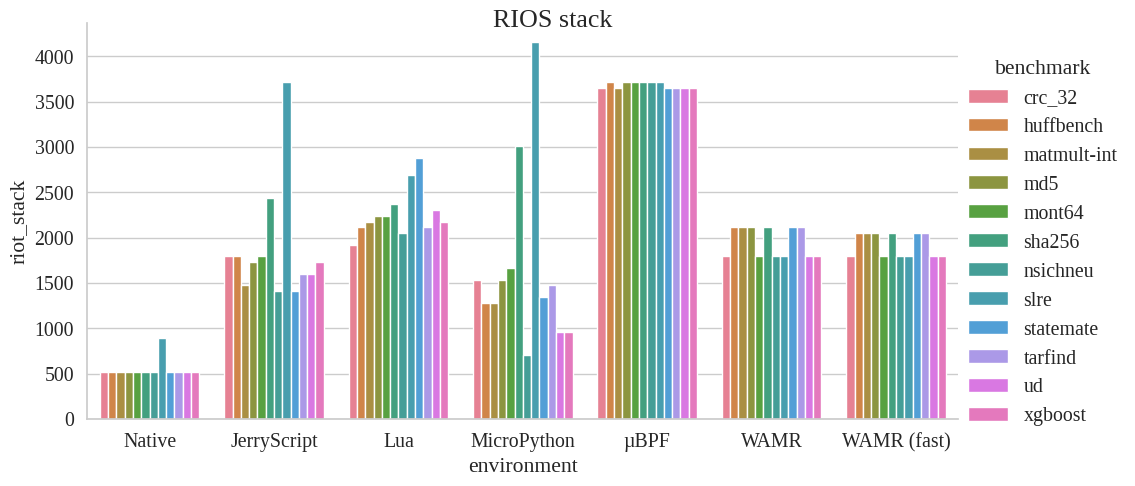

In [14]:
g = sns.catplot(stackfree_df, x="environment", y="riot_stack", hue="benchmark", aspect=2.0, kind="bar")
g.figure.suptitle("RIOS stack")

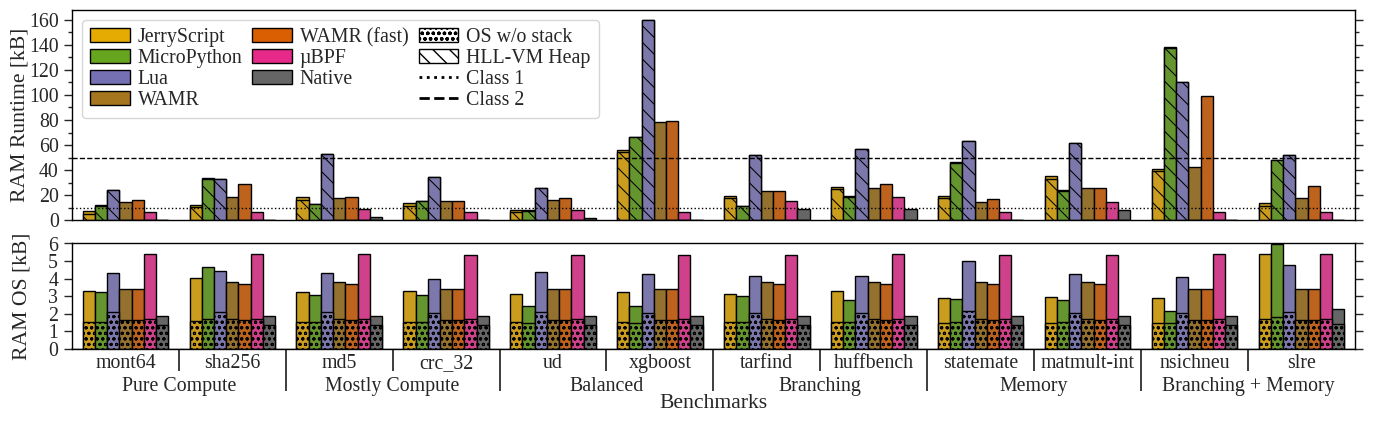

In [15]:
### FIGURE SETUP ###
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig, (ax_upper, ax_lower) = plt.subplots(2, 1, figsize=(14, 4.5), gridspec_kw={'height_ratios': [2, 1]})

### PLOTTING BARS (UPPER AXIS — RUNTIME + HEAP) ###
known_patches = set()
upper_bar = sns.barplot(ax=ax_upper, x="benchmark", y="sum", data=ram_categorized_df.with_columns(sum=pl.col("Runtime") + pl.col("Heap")), hue="environment", hue_order=bc_palette.keys(), palette=bc_palette)
set_hatch(upper_bar, known_patches, "")
heap_bar = sns.barplot(ax=ax_upper, x="benchmark", y="Heap", data=ram_categorized_df, hue="environment", hue_order=bc_palette.keys(), palette=bc_palette)
set_hatch(heap_bar, known_patches, "\\\\")

### PLOTTING BARS (LOWER AXIS — OS) ###
os_bar = sns.barplot(ax=ax_lower, x="benchmark", y="sum", data=ram_categorized_df.with_columns(sum=pl.col("Multi-Purpose OS")), hue="environment", hue_order=bc_palette.keys(), palette=bc_palette)
known_patches = set()
set_hatch(os_bar, known_patches, "")
os_stack_bar = sns.barplot(ax=ax_lower, x="benchmark", y="stack_free_os", data=stackfree_df, hue="environment", hue_order=bc_palette.keys(), palette=bc_palette)
set_hatch(os_stack_bar, known_patches, "ooo")

### REFERENCE LINES ###
ax_upper.hlines([50_000], -0.5, 11.5, color="black", linestyle="--", linewidth=1.0)
ax_upper.hlines([10_000], -0.5, 11.5, color="black", linestyle=":", linewidth=1.0)

### LEGEND ###
handles= [Patch(edgecolor="black", facecolor=c, label=language) for language, c in bc_palette.items()]
handles.append(Patch(edgecolor="none", facecolor="none", label=""))
handles.append(Patch(edgecolor="black", facecolor="none", label="OS w/o stack", hatch="ooo"))
handles.append(Patch(edgecolor="black", facecolor="none", label="HLL-VM Heap", hatch="\\\\"))
handles.extend(
    [
        Line2D([0], [0], color="black", linestyle=":", linewidth=2, label="Class 1"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Class 2")
    ]
)

ax_upper.legend(handles=handles, title="", loc="upper left", ncol=3, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5)
ax_lower.legend().remove()

### TEXT / LABELS ###
ax_upper.set_xlabel("")
ax_upper.set_ylabel("RAM Runtime [kB]", labelpad=0)
ax_upper.set_title("")
ax_lower.set_xlabel("Benchmarks")
ax_lower.set_ylabel("RAM OS [kB]", labelpad=12)

### AXIS LIMITS ###
ax_upper.set_xlim(-0.5, 11.5)
ax_lower.set_ylim(0, 6000)

### SECONDARY X-AXES (CATEGORY LABELS & DIVIDERS) ###
minx, maxx = ax.get_xlim()
sec = ax_lower.secondary_xaxis(location=0)
sec.set_xticks(np.arange(minx + 1, maxx, 2), labels=b_cat)

divider_axis = ax_lower.secondary_xaxis(location=0)
divider_axis.set_xticks(np.arange(minx + 2, maxx, 2), labels=[""] * 5)

ax_upper.set_xticklabels([])

### Y-AXIS FORMATTING ###
ax_upper.ticklabel_format(axis='y', style='sci', scilimits=(3,3))
ax_upper.yaxis.get_offset_text().set_visible(False)
set_yticks(ax_upper, 20000, 10000, both_sides=True)

ax_lower.ticklabel_format(axis='y', style='sci', scilimits=(3,3))
ax_lower.yaxis.get_offset_text().set_visible(False)
set_yticks(ax_lower, 1000, 1000, both_sides=True)

### PADDING ###
ax_lower.xaxis.labelpad = 15
ax_lower.tick_params(axis='x', pad=-2)
ax_lower.tick_params(axis='y', pad=4)
sec.tick_params(axis='x', pad=4)
sec.tick_params(axis='x', length=16)
divider_axis.tick_params(axis='x', length=30)

### GRID & FRAME ###
ax_upper.grid(False)
ax_lower.grid(False)
set_frame(ax_upper)
set_frame(ax_lower)

### LAYOUT & EXPORT ###
plt.subplots_adjust(hspace=0.15)
plt.tight_layout(h_pad=0.2)
plt.savefig("figures/ram_split.pdf", bbox_inches="tight", format="pdf")


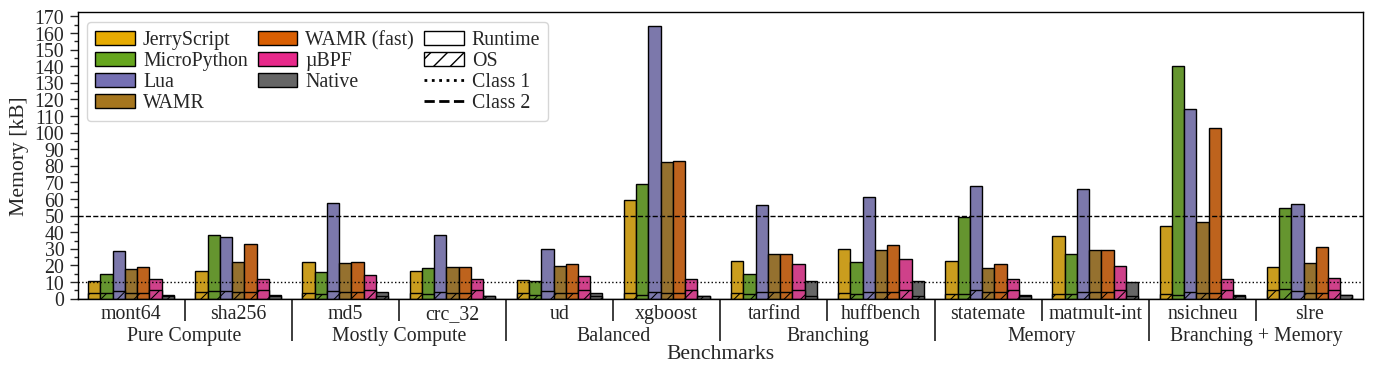

In [16]:
### FIGURE SETUP ###
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig, ax = plt.subplots(1, 1, figsize=(14, 4))

### PLOTTING BARS ###
known_patches = set()
upper_bar = sns.barplot(ax=ax, x="benchmark", y="sum", data=ram_categorized_df.with_columns(sum=pl.col("Multi-Purpose OS") + pl.col("Runtime") + pl.col("Heap")), hue="environment", hue_order=bc_palette.keys(), palette=bc_palette)
set_hatch(upper_bar, known_patches, "")
lower_bar = sns.barplot(ax=ax, x="benchmark", y="sum", data=ram_categorized_df.with_columns(sum=pl.col("Multi-Purpose OS")), hue="environment", hue_order=bc_palette.keys(), palette=bc_palette)
set_hatch(lower_bar, known_patches, "//")

### REFERENCE LINES ###
ax.hlines([50_000], -0.5, 11.5, color="black", linestyle="--", linewidth=1.0)
ax.hlines([10_000], -0.5, 11.5, color="black", linestyle=":", linewidth=1.0)

### LEGEND ###
handles= [Patch(edgecolor="black", facecolor=c, label=language) for language, c in bc_palette.items()]
handles.append(Patch(visible=False))
handles.append(Patch(edgecolor="black", facecolor="none", label="Runtime", hatch=""))
handles.append(Patch(edgecolor="black", facecolor="none", label="OS", hatch="//"))
handles.extend(
    [
        Line2D([0], [0], color="black", linestyle=":", linewidth=2, label="Class 1"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Class 2")
    ]
)
ax.legend(handles=handles, title="", loc="upper left", ncol=3, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5)

### TEXT / LABELS ###
ax.set_xlabel("Benchmarks")
ax.set_ylabel("Memory [kB]")
ax.set_title("")

### AXIS LIMITS ###
ax.set_xlim(-0.5, 11.5)

### SECONDARY X-AXES (CATEGORY LABELS & DIVIDERS) ###
minx, maxx = ax.get_xlim()
sec = ax.secondary_xaxis(location=0)
sec.set_xticks(np.arange(minx + 1, maxx, 2), labels=b_cat)

divider_axis = ax.secondary_xaxis(location=0)
divider_axis.set_xticks(np.arange(minx + 2, maxx, 2), labels=[""] * 5)

### Y-AXIS FORMATTING ###
ax.ticklabel_format(axis='y', style='sci', scilimits=(3,3))
ax.yaxis.get_offset_text().set_visible(False)
set_yticks(ax, 10000, 5000)

### PADDING ###
ax.xaxis.labelpad = 15
ax.tick_params(axis='x', pad=-2)
sec.tick_params(axis='x', pad=4)
sec.tick_params(axis='x', length=16)
divider_axis.tick_params(axis='x', length=30)

### GRID & FRAME ###
ax.grid(False)
set_frame(ax)

### LAYOUT & EXPORT ###
plt.tight_layout()
plt.savefig("figures/ram.pdf", bbox_inches="tight", format="pdf")


## RAM ROM combined

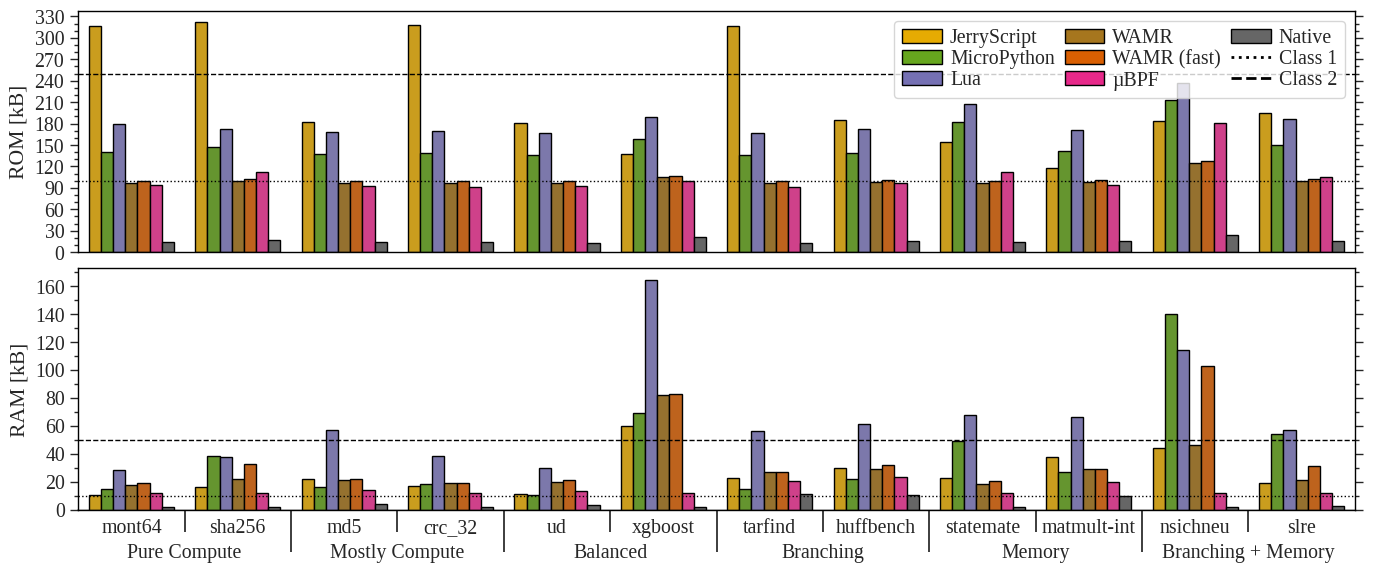

In [17]:
### FIGURE SETUP ###
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig, (ax_rom, ax_ram) = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={'height_ratios': [1, 1]})

### PLOTTING BARS ###
ram_bar = sns.barplot(ax=ax_ram, x="benchmark", y="sum", data=ram_categorized_df.with_columns(sum=pl.col("Multi-Purpose OS") + pl.col("Runtime") + pl.col("Heap")), hue="environment", hue_order=bc_palette.keys(), palette=bc_palette)
set_hatch(ram_bar, set(), "")
known_patches.update(ram_bar.patches)

rom_bar = sns.barplot(ax=ax_rom, x="benchmark", y="sum", data=rom_categorized_df.with_columns(sum=pl.col("Runtime") + pl.col("Multi-Purpose OS") + pl.col("Application")), hue="environment", hue_order=bc_palette.keys(), palette=bc_palette)
set_hatch(rom_bar, set(), "")
known_patches.update(rom_bar.patches)

### REFERENCE LINES ###
ax_ram.hlines([50_000], -0.5, 11.5, color="black", linestyle="--", linewidth=1.0)
ax_ram.hlines([10_000], -0.5, 11.5, color="black", linestyle=":", linewidth=1.0)
ax_rom.hlines([250_000], -0.5, 11.5, color="black", linestyle="--", linewidth=1.0)
ax_rom.hlines([100_000], -0.5, 11.5, color="black", linestyle="::", linewidth=1.0)

### LEGEND ###
handles= [Patch(edgecolor="black", facecolor=c, label=language) for language, c in bc_palette.items()]
handles.extend(
    [
        Line2D([0], [0], color="black", linestyle=":", linewidth=2, label="Class 1"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Class 2")
    ]
)

ax_rom.legend(handles=handles, title="", loc="upper right", ncol=3, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5)
ax_ram.legend().remove()

### TEXT / LABELS ###
ax_rom.set_xlabel("")
ax_rom.set_ylabel("ROM [kB]", labelpad=4)
ax_rom.set_title("")
ax_ram.set_xlabel("")
ax_ram.set_ylabel("RAM [kB]", labelpad=4)

### AXIS LIMITS ###
ax_ram.set_xlim(-0.5, 11.5)
ax_rom.set_xlim(-0.5, 11.5)

### SECONDARY X-AXES (CATEGORY LABELS & DIVIDERS) ###
minx, maxx = ax_ram.get_xlim()
sec = ax_ram.secondary_xaxis(location=0)
sec.set_xticks(np.arange(minx + 1, maxx, 2), labels=b_cat)

divider_axis = ax_ram.secondary_xaxis(location=0)
divider_axis.set_xticks(np.arange(minx + 2, maxx, 2), labels=[""] * 5)

ax_rom.set_xticklabels([])

### Y-AXIS FORMATTING ###
ax_ram.ticklabel_format(axis='y', style='sci', scilimits=(3,3))
ax_ram.yaxis.get_offset_text().set_visible(False)
set_yticks(ax_ram, 20000, 10000, both_sides=True)

ax_rom.ticklabel_format(axis='y', style='sci', scilimits=(3,3))
ax_rom.yaxis.get_offset_text().set_visible(False)
set_yticks(ax_rom, 30_000, 10_000, both_sides=True)

### PADDING ###
ax_rom.tick_params(axis='y', pad=4)
ax_ram.tick_params(axis='x', pad=0)
sec.tick_params(axis='x', pad=8)
sec.tick_params(axis='x', length=16)
divider_axis.tick_params(axis='x', length=30)

### GRID & FRAME ###
ax_ram.grid(False)
ax_rom.grid(False)
set_frame(ax_ram)
set_frame(ax_rom)

### LAYOUT & EXPORT ###
plt.subplots_adjust(hspace=0.15)
plt.tight_layout(h_pad=0.2)
plt.savefig("figures/rom_ram_split.pdf", bbox_inches="tight", format="pdf")
